# P9 — Does the regime layer pay rent? (gate N7)

**Question:** over the honest walk-forward (1972–2020, point-in-time data, month-end P&L, 10 bps costs), does
tilting the core mix by the regime belief beat the same mix with the tilt switched off, by enough
to survive the multiple-testing hurdle?

Everything below is read from tracked outputs of the last budgeted run (8.3's month-end run, registry
tag `08.3-monthend-tilt-vs-ablation`). Only the three price baselines are recomputed, by deterministic
arithmetic with no registry trial. Nothing is fitted.

**Prerequisites — run these first if the artifacts below are missing:**

- `python scripts/build_platform_data.py` (the `monthly_raw` the baselines are rebuilt from)
- the backtest outputs are tracked; a budgeted `python -m trading_crab_lib.platform.evaluation.report`
  run is the only thing that rewrites them


In [1]:
%matplotlib inline
import contextlib
import io
import logging
import shutil

import numpy as np
from IPython.display import Markdown, display

logging.basicConfig(level=logging.WARNING)

from trading_crab_lib.platform import plotting as pplot
from trading_crab_lib.platform.config import load_platform_config
from trading_crab_lib.platform.honesty.registry import total_trial_count
from trading_crab_lib.platform.evaluation.deflated_sharpe import expected_max_sharpe, quality_tier
from trading_crab_lib.platform.plotting import backtest as pbacktest
from trading_crab_lib.platform.report import scoreboard

REPORT_HINT = "python -m trading_crab_lib.platform.evaluation.report"
DATA_HINT = "python scripts/build_platform_data.py"

cfg = load_platform_config()
safe_cfg = pplot.redacted_config(cfg)  # never display cfg itself (T-06-01)
print("cost:", safe_cfg["backtest"]["cost_bps"], "bps; scoreboard tag:", safe_cfg["report"]["scoreboard_trial_tag"])
n_trials = total_trial_count()
print("registry trials (live):", n_trials)


cost: 10 bps; scoreboard tag: 08.3-monthend-tilt-vs-ablation
registry trials (live): 48


## 1. Before and after month-end P&L (E-07 → E-12)

8.3 re-measured the same walk-forward on month-end to month-end returns (E-08); features and labels did
not change. "Before" is the reproduction of 8.1's run on average-price returns, kept in
`pit_08.3/before/`; "after" is the run the scoreboard reads. For 8.1's point-in-time before | after
(the audit fix itself), see DECISIONS E-06.

In [2]:
before = pplot.load_report_artifact("pit_08.3/before/backtest_kpi_table.parquet", rebuild_hint=REPORT_HINT)
after = pplot.load_report_artifact("backtest_kpi_table.parquet", rebuild_hint=REPORT_HINT)
before_after = scoreboard.before_after_table(before, after)
print(before_after.to_string(index=False, float_format=lambda v: f"{v:.4f}"))


               leg  tlw_before  tlw_after  tlw_delta  mdd_before  mdd_after  mdd_delta
          strategy      3.8909     3.8789    -0.0120     -0.2390    -0.2696    -0.0305
no_regime_ablation      4.0424     4.1124     0.0700     -0.1983    -0.2060    -0.0077
      spy_buy_hold      5.6882     5.7471     0.0589     -0.4917    -0.5109    -0.0192
       sixty_forty      5.0404     5.1187     0.0783     -0.2715    -0.2949    -0.0234
         faber_sma      6.4285     5.7114    -0.7171     -0.1898    -0.2338    -0.0441


## 2. The scoreboard, as the weekly page prints it

All five legs on the same months (the strategy curve's window); the KPI table's own-span numbers
are a footnote because the baselines start ten years earlier.


In [3]:
board = scoreboard.scoreboard_table(cfg)
assert board["reconciled"], board["reason"]
display(Markdown("\n".join(scoreboard.format_scoreboard(board))))


## Scoreboard (static — last budgeted run)

| Leg | TLW 1972–2020 | MDD 1972–2020 |
|---|---|---|
| Regime tilt (strategy) | 3.8789 | -26.96% |
| No-regime ablation | 4.1124 | -20.60% |
| SPY buy & hold | 4.9900 | -51.09% |
| 60/40 | 4.5098 | -29.49% |
| Faber 10-mo SMA | 4.9759 | -23.38% |

Own-span TLW (backtest_kpi_table.parquet): Regime tilt (strategy) 3.8789; No-regime ablation 4.1124; SPY buy & hold 5.7471 (from 1962-05); 60/40 5.1187 (from 1962-05); Faber 10-mo SMA 5.7114 (from 1962-02). The table above puts all five legs on the same months, so its numbers are comparable; the own-span ones are not.

Run 2026-10-04 (registry tag 08.3-monthend-tilt-vs-ablation) · window 1972-01-31 → 2020-12-31 · 588 monthly steps · 10 bps

Caveat (E-07): scoreboard returns are month-end to month-end, except oil before 1986, which uses monthly-average WTI (a bounded exception, E-08; D-02).


## 3. Five equity curves on the common window

strategy             588 months 1972-01-31 -> 2020-12-31
no_regime_ablation   588 months 1972-01-31 -> 2020-12-31
spy_buy_hold         588 months 1972-01-31 -> 2020-12-31
sixty_forty          588 months 1972-01-31 -> 2020-12-31
faber_sma            588 months 1972-01-31 -> 2020-12-31


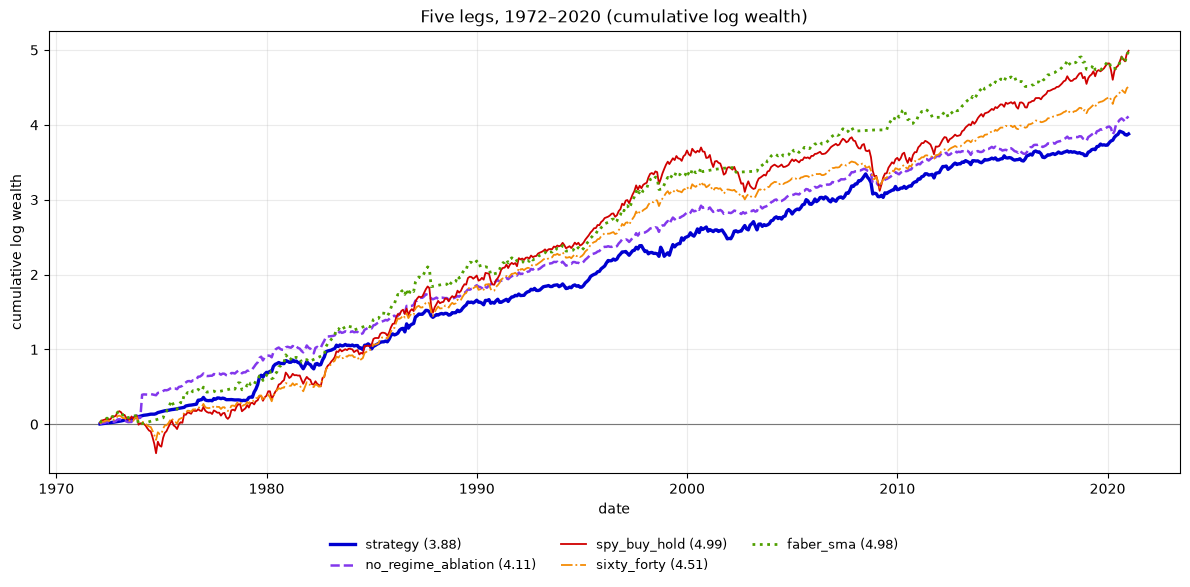

In [4]:
strategy_curve = pplot.load_report_artifact("backtest_equity_curve_strategy.parquet", rebuild_hint=REPORT_HINT)
ablation_curve = pplot.load_report_artifact("backtest_equity_curve_ablation.parquet", rebuild_hint=REPORT_HINT)
monthly_raw = pplot.load_platform_checkpoint("monthly_raw", rebuild_hint=DATA_HINT)
baselines = pbacktest.recompute_baseline_curves(monthly_raw, cfg)
window = strategy_curve.index
curves = {
    "strategy": strategy_curve["return"],
    "no_regime_ablation": ablation_curve["return"],
    **{name: series.loc[window[0]:window[-1]] for name, series in baselines.items()},
}
for name, series in curves.items():
    print(f"{name:<20} {len(series.dropna())} months {series.index.min().date()} -> {series.index.max().date()}")
fig_curves = pbacktest.plot_equity_curves(
    curves, title=f"Five legs, {window[0].year}–{window[-1].year} (cumulative log wealth)"
)


## 4. Sharpe against the deflated-Sharpe hurdle

A leg "pays" only if its annualized Sharpe clears `expected_max_sharpe(n_trials, variance)`: the
best Sharpe pure luck would produce after this many trials (ADR-0003, the A11 gate). The trial
count is the live registry count; the Sharpe variance is 1.0, E-06's placeholder.


hurdle at 48 trials: 2.2606
strategy             Sharpe 0.9149  DSR 0.0000  clears: False
no_regime_ablation   Sharpe 0.9885  DSR 0.0000  clears: False
spy_buy_hold         Sharpe 0.7477  DSR 0.0000  clears: False
sixty_forty          Sharpe 0.9898  DSR 0.0000  clears: False
faber_sma            Sharpe 0.9407  DSR 0.0000  clears: False


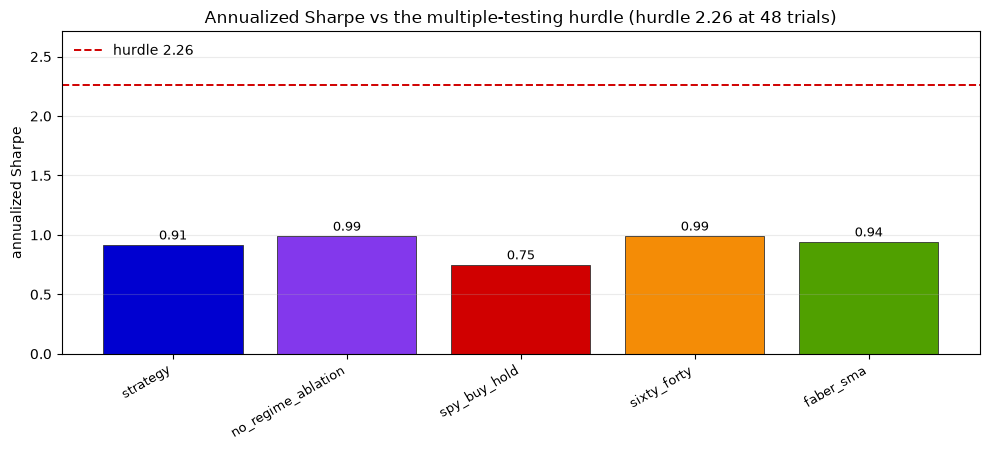

In [5]:
SHARPE_VARIANCE = 1.0
hurdle = expected_max_sharpe(n_trials, SHARPE_VARIANCE)
tiers = {name: quality_tier(series, n_trials=n_trials, sharpe_variance=SHARPE_VARIANCE) for name, series in curves.items()}
print(f"hurdle at {n_trials} trials: {hurdle:.4f}")
for name, tier in tiers.items():
    print(f"{name:<20} Sharpe {tier['observed_sharpe']:.4f}  DSR {tier['dsr']:.4f}  clears: {tier['ok']}")
fig_hurdle = pbacktest.plot_sharpe_vs_hurdle(
    {name: tier["observed_sharpe"] for name, tier in tiers.items()}, hurdle, n_trials=n_trials
)


In [6]:
print(scoreboard.E07_CAVEAT)

Caveat (E-07): scoreboard returns are month-end to month-end, except oil before 1986, which uses monthly-average WTI (a bounded exception, E-08; D-02).


## 5. Guard: the answer below must still be true

If a later budgeted run rewrites the outputs so that the tilt beats the ablation, any leg clears the
hurdle, or a baseline now qualifies under the E-09 rule, this cell fails and the answer below must
be revisited before sign-off.

In [7]:
# E-12's recorded outcomes (DECISIONS E-12, registry tag 08.3-monthend-tilt-vs-ablation).
RECORDED_TILT_LOSES = True        # strategy TLW < ablation TLW
RECORDED_CLEARS_HURDLE = {name: False for name in curves}   # no leg clears the DSR hurdle at 48
RECORDED_QUALIFIERS = set()       # E-09: no candidate beats the no-regime mix on both TLW and MDD

legs = {row["leg"]: row for row in board["legs"]}
core = legs["no_regime_ablation"]
assert (legs["strategy"]["tlw_common"] < core["tlw_common"]) == RECORDED_TILT_LOSES, (
    "the tilt-vs-ablation sign moved: revisit the answer")
for name, tier in tiers.items():
    assert tier["ok"] == RECORDED_CLEARS_HURDLE[name], f"{name} hurdle verdict moved: revisit the answer"
qualifiers = {
    leg for leg in ("faber_sma", "spy_buy_hold", "sixty_forty")
    if legs[leg]["tlw_common"] > core["tlw_common"] and legs[leg]["mdd_common"] > core["mdd_common"]
}
assert qualifiers == RECORDED_QUALIFIERS, f"the E-09 qualifier set is now {sorted(qualifiers)}: revisit the answer"
assert total_trial_count() == n_trials, "a registry row was appended: revisit the answer"
print(f"guard passed: tilt TLW {legs['strategy']['tlw_common']:.4f} < ablation TLW {core['tlw_common']:.4f}; "
      f"E-09 qualifiers: {sorted(qualifiers) or 'none'}; no leg clears the hurdle {hurdle:.4f} at {n_trials} trials")


guard passed: tilt TLW 3.8789 < ablation TLW 4.1124; E-09 qualifiers: none; no leg clears the hurdle 2.2606 at 48 trials


## Answer

**No — the regime view stays advisory (G-06), and the core mix stands.**

**Tilt vs ablation:** No — on month-end P&L the L2-posterior-driven regime tilt (ruling 2) ends at
terminal log wealth 3.8789 against the no-regime ablation's 4.1124 net of 10 bps in the same run (delta
−0.2336, wider than 8.1's −0.1515), so it does not beat the ablation, with its inputs still estimated on
average prices (E-10 b; the vol-target miscalibration is E-11, deferred to 08.4). Its max drawdown is
−27.0% against −20.6%, its annualized Sharpe 0.91 against 0.99, and neither leg comes near the
multiple-testing hurdle (2.26 at 48 trials).

**Core mix:** The core mix stands: on the common 1972–2020 window no candidate beats the no-regime mix
(4.1124, −20.60%) on both measures, because Faber (4.9759, −23.38%), SPY (4.9900, −51.09%) and 60/40
(4.5098, −29.49%) all earn more but draw down deeper, so A-13 stays `no_regime` and no switch is built.

The weekly page therefore keeps trading the no-regime core mix (A-13) and keeps the regime view
suspended until the regime rebuild re-measures it. The remaining E-07 exception is oil before 1986
(monthly-average WTI, a bounded exception, E-08).

## N7 Sign-Off

Glenn fills this in after reading the notebook top to bottom (D-15 style: a plain cell, no helper,
no ledger).

**Date:** _pending_

**Verdict:** _pending_ (approve / approve with notes / reject)

**Reasoning:** _pending_
